In [7]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib inline

csv_path = "C:/Users/rahim/Downloads/Retail Sales Analytics Dataset/retail_sales_dataset.csv"

df = pd.read_csv(csv_path)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [9]:
df.info()
df.describe(include='all').transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction ID,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
Date,1000,345,2023-05-16,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,1000,1000,CUST001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1000,2,Female,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1000.0,NaN,NaN,NaN,41.392,13.68143,18.0,29.0,42.0,53.0,64.0
Product Category,1000,3,Clothing,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1000.0,NaN,NaN,NaN,2.514,1.132734,1.0,1.0,3.0,4.0,4.0
Price per Unit,1000.0,NaN,NaN,NaN,179.89,189.681356,25.0,30.0,50.0,300.0,500.0
Total Amount,1000.0,NaN,NaN,NaN,456.0,559.997632,25.0,60.0,135.0,900.0,2000.0


In [11]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows:
0


In [13]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()

# Detect date columns
date_cols = [c for c in df.columns if "date" in c.lower()]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)
print("Date columns:", date_cols)

Numeric columns: ['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount']
Categorical columns: ['Date', 'Customer ID', 'Gender', 'Product Category']
Date columns: ['Date']


In [15]:
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')

df[date_cols].head()

,Date
0,2023-11-24
1,2023-02-27
2,2023-01-13
3,2023-05-21
4,2023-05-06


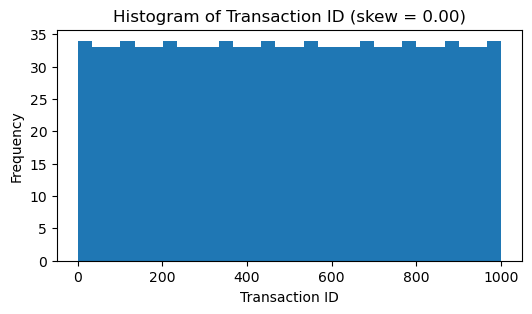

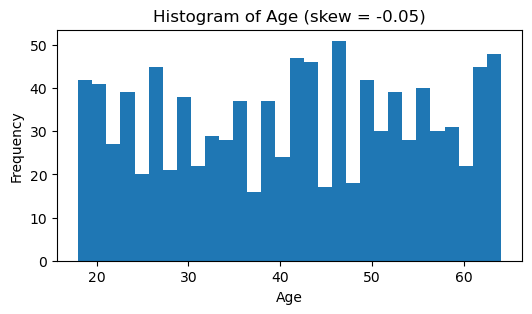

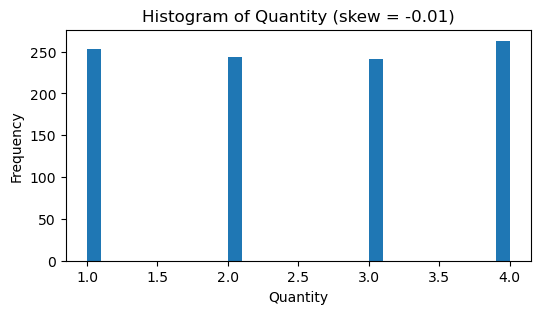

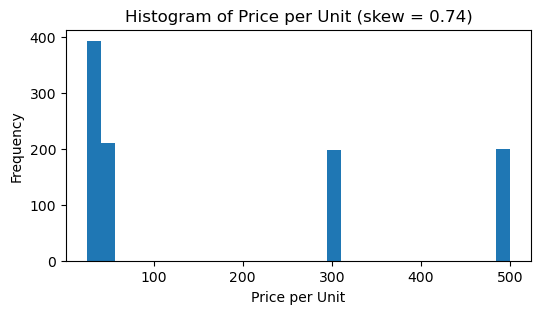

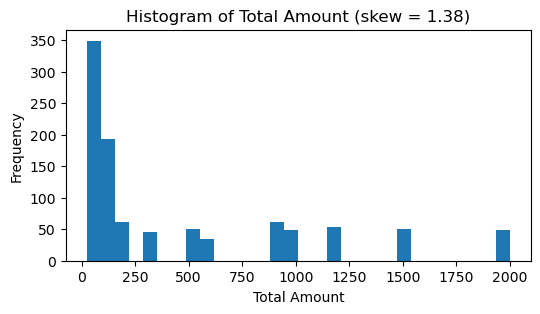

In [17]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Histogram of {col} (skew = {df[col].dropna().skew():.2f})")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

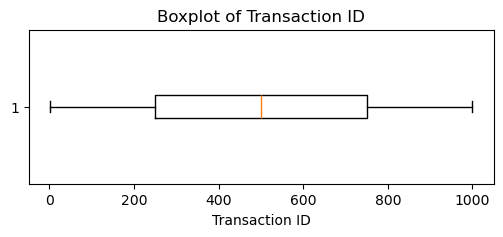

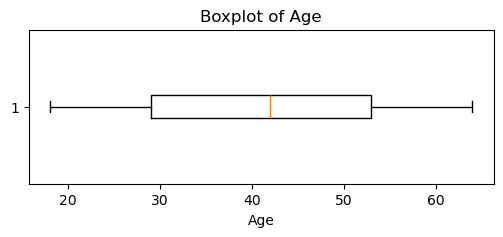

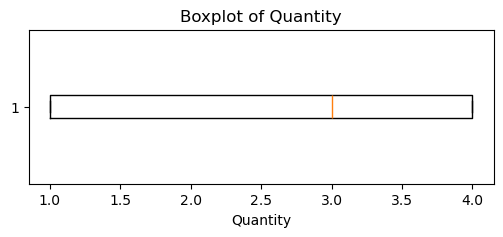

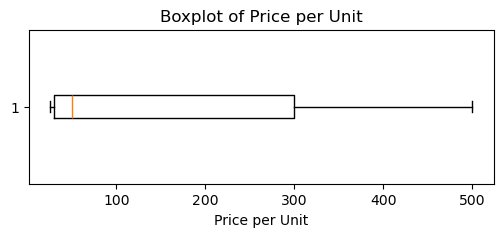

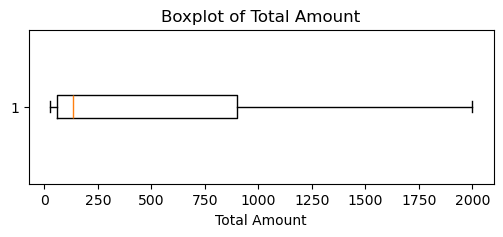

In [19]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

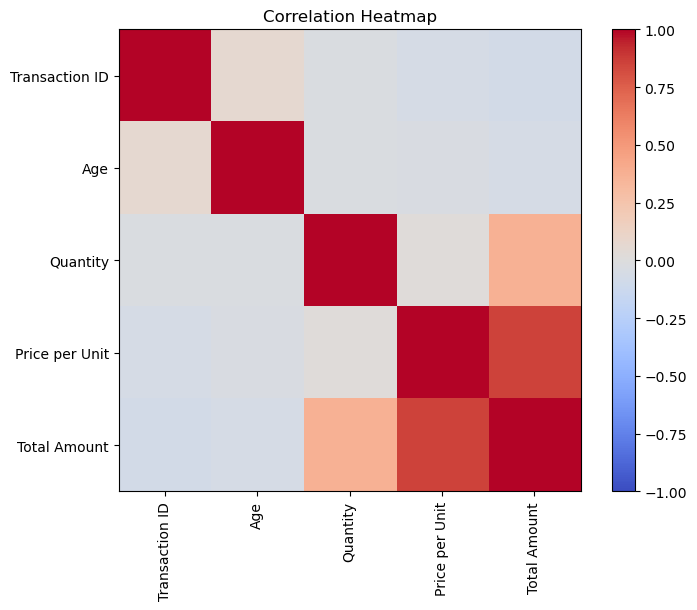

In [21]:
if len(num_cols) >= 2:
    corr = df[num_cols].corr()

    plt.figure(figsize=(8,6))
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.xticks(range(len(num_cols)), num_cols, rotation=90)
    plt.yticks(range(len(num_cols)), num_cols)
    plt.colorbar()
    plt.title("Correlation Heatmap")
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap.")

In [23]:
for col in cat_cols:
    print(f"\nTop values for {col}:")
    print(df[col].value_counts().head(10))


Top values for Date:
Date
2023-05-16    11
2023-07-14    10
2023-05-23     9
2023-08-05     8
2023-02-05     8
2023-10-11     7
2023-04-23     7
2023-11-02     6
2023-12-23     6
2023-04-19     6
Name: count, dtype: int64

Top values for Customer ID:
Customer ID
CUST001    1
CUST672    1
CUST659    1
CUST660    1
CUST661    1
CUST662    1
CUST663    1
CUST664    1
CUST665    1
CUST666    1
Name: count, dtype: int64

Top values for Gender:
Gender
Female    510
Male      490
Name: count, dtype: int64

Top values for Product Category:
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


Possible sales columns: ['Price per Unit', 'Total Amount']


C:\Users\rahim\AppData\Local\Temp\ipykernel_17180\4197110700.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key=date_col, freq="M")


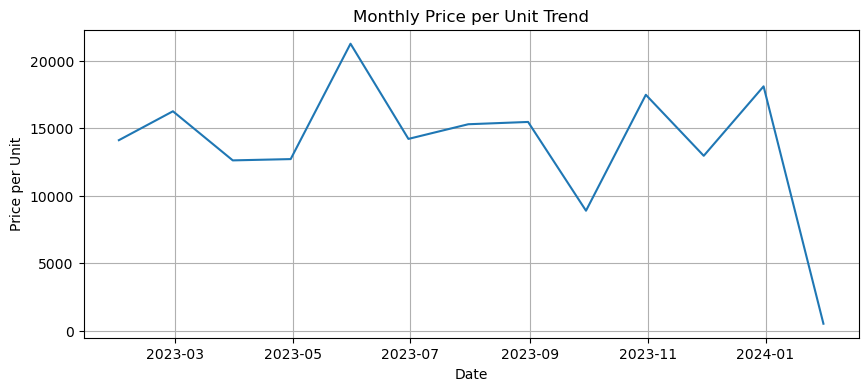

In [25]:
# Try to find sales column automatically
sales_cols = [c for c in df.columns if any(x in c.lower() for x in ["total", "amount", "sales", "revenue", "price"])]

print("Possible sales columns:", sales_cols)

if date_cols and sales_cols:
    date_col = date_cols[0]
    sales_col = sales_cols[0]

    ts = df[[date_col, sales_col]].dropna().groupby(
        pd.Grouper(key=date_col, freq="M")
    )[sales_col].sum()

    plt.figure(figsize=(10,4))
    plt.plot(ts.index, ts.values)
    plt.title(f"Monthly {sales_col} Trend")
    plt.xlabel("Date")
    plt.ylabel(sales_col)
    plt.grid(True)
    plt.show()
else:
    print("No valid date + sales combination found.")

In [27]:
pdf_path = "Retail_Sales_EDA_Report.pdf"
with PdfPages(pdf_path) as pdf:
    
    # Example: Add a summary page
    fig = plt.figure(figsize=(8,11))
    plt.axis('off')
    summary = f"Retail Sales Analytics — EDA Report\n\nRows: {df.shape[0]}\nColumns: {df.shape[1]}"
    plt.text(0.1, 0.9, summary, fontsize=12)
    pdf.savefig(fig); plt.close()

    # Add histograms
    for col in num_cols:
        fig = plt.figure(figsize=(6,3))
        plt.hist(df[col].dropna(), bins=30)
        plt.title(f"Histogram of {col}")
        pdf.savefig(fig); plt.close()

print("PDF exported at:", pdf_path)

PDF exported at: Retail_Sales_EDA_Report.pdf
